# Microproyecto 2 — Clasificación de textos según los Objetivos de Desarrollo Sostenible

**Machine Learning No Supervisado**

## 1. Introducción

La ONU adoptó en 2015 la Agenda 2030, que define 17 Objetivos de Desarrollo Sostenible (ODS). Entidades como el Fondo de Población de las Naciones Unidas (UNFPA) necesitan revisar grandes cantidades de texto (documentos públicos, resúmenes de artículos, reportes, opiniones ciudadanas) y decidir con qué ODS se relaciona cada uno. Hoy ese trabajo lo hacen expertos de forma manual, lo que consume mucho tiempo.

En este microproyecto construimos una solución de procesamiento de lenguaje natural que hace esa asignación de forma automática. El plan de trabajo es el que pide el enunciado:

1. Preparar los textos con un esquema de bolsa de palabras con pesado TF-IDF, dentro de un *pipeline*.
2. Aplicar SVD truncado sobre la matriz TF-IDF para obtener un modelo de tópicos (LSA) e interpretar al menos 5 tópicos frente a los ODS.
3. Entrenar un modelo de clasificación que relacione un texto con un ODS, usando reducción de dimensionalidad.
4. Evaluar el modelo con textos que no se usaron durante el aprendizaje.

Al final guardamos el modelo entrenado para reutilizarlo en una aplicación de Streamlit.

## 2. Importación de librerías y carga de datos

Trabajamos con las librerías vistas en los tutoriales del curso: `nltk` para el procesamiento de texto, `scikit-learn` para la vectorización, la reducción de dimensionalidad y los modelos, y `pandas` / `matplotlib` / `seaborn` para explorar y graficar.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import nltk
nltk.download('stopwords', quiet=True)
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

Los datos vienen en un archivo de Excel con los textos ya traducidos al español. Lo leemos con `pd.read_excel()`.

In [2]:
RUTA = '../94f47dfe96414485b5def55bccbd7cb8_Datos_textosODS.xlsx'
datos = pd.read_excel(RUTA)
print('Forma del conjunto:', datos.shape)
datos.head()

Forma del conjunto: (9656, 2)


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9656 entries, 0 to 9655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   textos  9656 non-null   object
 1   ODS     9656 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 151.0+ KB


## 3. Exploración de los datos

Antes de procesar nada revisamos qué tenemos: cuántos textos hay por objetivo, qué tan largos son y si hay registros nulos o repetidos.

In [4]:
print('Nulos por columna:\n', datos.isna().sum())
print('\nRegistros duplicados:', datos.duplicated().sum())
print('\nObjetivos presentes:', sorted(datos['ODS'].unique()))

Nulos por columna:
 textos    0
ODS       0
dtype: int64

Registros duplicados: 0

Objetivos presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


No hay nulos ni duplicados, así que no necesitamos hacer limpieza de registros. Un detalle importante: aunque la Agenda 2030 tiene 17 objetivos, en el conjunto solo aparecen los ODS del 1 al 16. El ODS 17 ("Alianzas para lograr los objetivos") no tiene textos etiquetados, de modo que **nuestro problema es de 16 clases** y el modelo nunca podrá predecir el ODS 17.

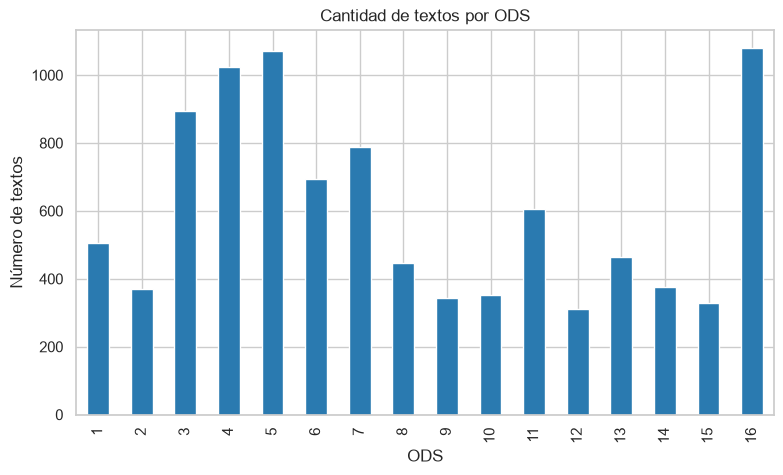

ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64

In [5]:
NOMBRES_ODS = {
    1: 'Fin de la pobreza', 2: 'Hambre cero', 3: 'Salud y bienestar',
    4: 'Educación de calidad', 5: 'Igualdad de género', 6: 'Agua limpia y saneamiento',
    7: 'Energía asequible y no contaminante', 8: 'Trabajo decente y crecimiento económico',
    9: 'Industria, innovación e infraestructura', 10: 'Reducción de las desigualdades',
    11: 'Ciudades y comunidades sostenibles', 12: 'Producción y consumo responsables',
    13: 'Acción por el clima', 14: 'Vida submarina', 15: 'Vida de ecosistemas terrestres',
    16: 'Paz, justicia e instituciones sólidas', 17: 'Alianzas para lograr los objetivos',
}

conteo = datos['ODS'].value_counts().sort_index()
ax = conteo.plot(kind='bar', color='#2a7ab0')
ax.set_title('Cantidad de textos por ODS')
ax.set_xlabel('ODS'); ax.set_ylabel('Número de textos')
plt.show()
conteo

Las clases no están balanceadas: el ODS 16 y el ODS 5 superan los mil textos, mientras que el ODS 12 apenas llega a 312. La diferencia es de un poco más de tres veces entre la clase mayor y la menor. No es un desbalance extremo, pero sí suficiente para que **no podamos usar la exactitud como única métrica**: un modelo que acierte bien en las clases grandes podría verse bueno mientras falla en las pequeñas. Más adelante usaremos el F1 macro justamente por esta razón.

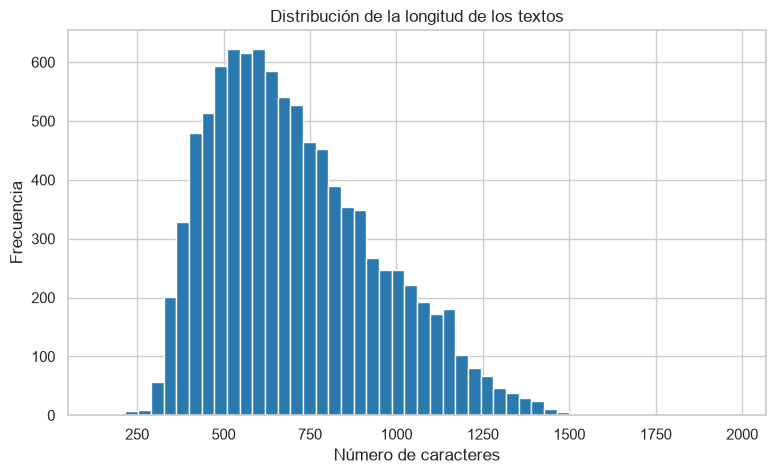

count    9656.000000
mean      708.952465
std       238.864636
min       143.000000
25%       522.000000
50%       669.000000
75%       864.000000
max      1977.000000
Name: textos, dtype: float64

In [6]:
longitudes = datos['textos'].str.len()
plt.hist(longitudes, bins=50, color='#2a7ab0')
plt.title('Distribución de la longitud de los textos')
plt.xlabel('Número de caracteres'); plt.ylabel('Frecuencia')
plt.show()
longitudes.describe()

Los textos son párrafos de tamaño medio: la mediana está cerca de los 670 caracteres y casi todos caben entre 500 y 900. Son lo bastante largos como para contener varias palabras informativas, que es lo que necesita una representación de bolsa de palabras.

## 4. Preprocesamiento de los textos

Siguiendo el tutorial de procesamiento de textos, aplicamos los pasos clásicos. La función completa está en el archivo `preprocesamiento.py` y hace lo siguiente:

1. **Minúsculas y eliminación de tildes.** Así "Educación", "educación" y "educacion" se vuelven el mismo token. Al quitar los signos diacríticos la "ñ" también queda como "n".
2. **Tokenización con `RegexpTokenizer(r'[a-z]+')`.** Nos quedamos solo con palabras y descartamos números y signos de puntuación, que no aportan al tema del texto.
3. **Eliminación de palabras vacías.** Usamos la lista de `stopwords` en español de `nltk` y le añadimos una lista propia de términos que son frecuentes en todo el corpus pero no distinguen un objetivo de otro ("ods", "desarrollo", "sostenible", "agenda", "país"...). Si dejáramos esas palabras, aparecerían en todos los tópicos sin aportar información.
4. **Descarte de tokens de menos de 3 letras**, que suelen ser restos de la tokenización.
5. **Stemming con `SnowballStemmer('spanish')`.** El tutorial usa `PorterStemmer`, pero ese algoritmo solo funciona para inglés: no reduciría "educación", "educativo" y "educar" a una raíz común. El *stemmer* de Snowball sí tiene reglas para español, así que lo cambiamos.

Escogimos stemming y no lematización porque la lematización en español exige un modelo adicional (por ejemplo spaCy) y es mucho más lenta, mientras que para una bolsa de palabras basta con que las variantes de una palabra caigan en el mismo token.

### ¿Por qué en un archivo aparte y no en el notebook?

El `TfidfVectorizer` recibe esta función en su parámetro `preprocessor`. Cuando guardemos el modelo con `joblib`, la función no se guarda dentro del archivo: lo que se guarda es una referencia al módulo donde fue definida. Si la definiéramos aquí, esa referencia sería `__main__.limpiar_texto` y la aplicación de Streamlit no podría cargar el modelo. Teniéndola en `preprocesamiento.py`, tanto el notebook como la aplicación la importan del mismo sitio y la referencia siempre resuelve.

In [7]:
from preprocesamiento import limpiar_texto, PALABRAS_VACIAS

print('Palabras vacías utilizadas:', len(PALABRAS_VACIAS))
ejemplo = datos['textos'].iloc[0]
print('\nTEXTO ORIGINAL:\n', ejemplo[:400])
print('\nTEXTO PROCESADO:\n', limpiar_texto(ejemplo)[:400])

Palabras vacías utilizadas: 347

TEXTO ORIGINAL:
 "Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formación de docentes, se consideran extensiones de los acuerdos establecidos por los gobiernos. Este marco de comprensión se ha vuelto cada vez más inadecuado.

TEXTO PROCESADO:
 aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt vez inadecu


El resultado ya no tiene tildes, ni artículos, ni preposiciones, y las palabras quedaron reducidas a su raíz ("educacion" pasa a "educ", "organizaciones" a "organiz"). Se lee mal para una persona, pero es exactamente lo que necesita el vectorizador.

Veamos ahora qué vocabulario domina el corpus con una nube de palabras.

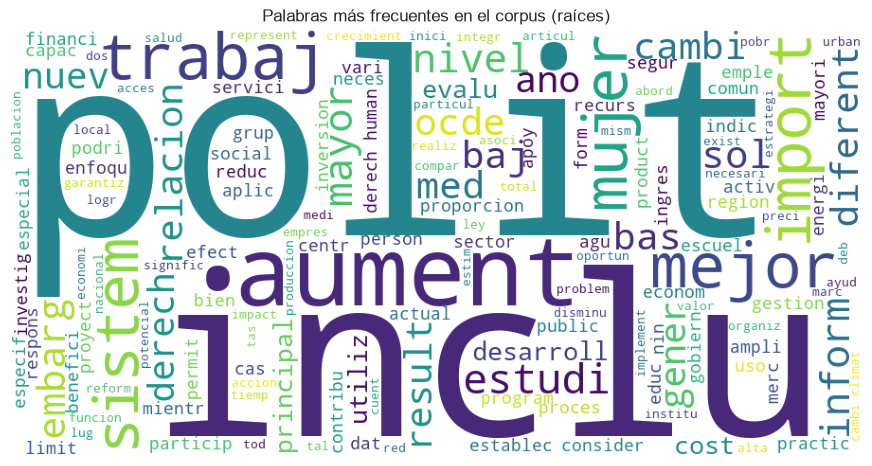

In [8]:
muestra = datos['textos'].sample(2000, random_state=RANDOM_STATE).apply(limpiar_texto)
nube = WordCloud(width=900, height=450, background_color='white',
                 max_words=150, colormap='viridis').generate(' '.join(muestra))
plt.figure(figsize=(11, 6))
plt.imshow(nube); plt.axis('off')
plt.title('Palabras más frecuentes en el corpus (raíces)')
plt.show()

Las raíces más grandes son "polit", "derech", "mujer", "trabaj", "agu", "educ" y "energi", vocabulario que apunta directamente a objetivos como el 16, el 5, el 6, el 4 y el 7. Es buena señal: el corpus habla efectivamente de los temas de la Agenda 2030.

Junto a ellas aparecen raíces muy generales como "mejor", "nivel", "mayor" o "aument", que salen en textos de todos los objetivos y no ayudan a distinguir ninguno. No las añadimos a la lista de palabras vacías porque el pesado TF-IDF del siguiente paso ya se encarga de bajarles el peso justamente por ser tan comunes. Usamos una muestra de 2.000 textos para que la nube se genere rápido.

## 5. Separación en entrenamiento y prueba

Separamos **antes** de ajustar cualquier transformación. Esto es importante: si calculáramos el TF-IDF sobre todo el conjunto, el vocabulario y los pesos IDF incluirían información de los textos de prueba y la evaluación quedaría contaminada. Dejando la partición primero, el conjunto de prueba queda realmente fuera del aprendizaje, como pide la actividad 4.

Usamos `stratify=y` para que cada ODS conserve la misma proporción en ambos conjuntos, algo necesario dado el desbalance que vimos.

In [9]:
X = datos['textos']
y = datos['ODS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f'Entrenamiento: {X_train.shape[0]} textos')
print(f'Prueba:        {X_test.shape[0]} textos')

Entrenamiento: 7724 textos
Prueba:        1932 textos


## 6. Representación TF-IDF (bolsa de palabras con pesado)

Construimos la matriz de bolsa de palabras con `TfidfVectorizer`, que combina en un solo paso el conteo de términos y el pesado TF-IDF. Las decisiones que tomamos y su justificación:

| Parámetro | Valor | Por qué |
|---|---|---|
| `preprocessor` | `limpiar_texto` | Integra todo el procesamiento de `nltk` dentro del vectorizador, de modo que el *pipeline* recibe el texto crudo. |
| `ngram_range` | `(1, 2)` | Además de palabras sueltas guardamos parejas. Expresiones como "cambio climático", "salud mental" o "igualdad de género" significan mucho más juntas que separadas. |
| `min_df` | `5` | Descarta términos que aparecen en menos de 5 documentos. Son casi siempre erratas o palabras muy específicas que solo añaden ruido y dimensiones. |
| `max_df` | `0.8` | Descarta términos presentes en más del 80% de los documentos, que por definición no sirven para diferenciar clases. |
| `sublinear_tf` | `True` | Aplica `1 + log(tf)` en vez de la frecuencia cruda, para que una palabra repetida diez veces no pese diez veces más que una que aparece una sola vez. |

Usamos TF-IDF y no conteos simples porque el pesado castiga las palabras comunes a todo el corpus y resalta las que son características de un documento, que es justo lo que distingue un ODS de otro.

In [10]:
vectorizador = TfidfVectorizer(preprocessor=limpiar_texto, ngram_range=(1, 2),
                               min_df=5, max_df=0.8, sublinear_tf=True)
tfidf_train = vectorizador.fit_transform(X_train)
terminos = vectorizador.get_feature_names_out()

print('Matriz TF-IDF:', tfidf_train.shape)
print(f'Densidad: {tfidf_train.nnz / (tfidf_train.shape[0] * tfidf_train.shape[1]):.4%}')
print('\nAlgunos términos del vocabulario:', list(terminos[3000:3015]))

Matriz TF-IDF: (7724, 12281)
Densidad: 0.4188%

Algunos términos del vocabulario: ['delhi', 'deliber', 'delict', 'delimit', 'delin', 'delincuent', 'delincuent organiz', 'delit', 'delit genocidi', 'delit relacion', 'deloitt', 'dem', 'demand', 'demand agu', 'demand aliment']


Obtenemos una matriz de 7.724 textos por más de 12.000 términos, y solo alrededor del 0,5% de las celdas tiene un valor distinto de cero. Esa dispersión es la razón de fondo por la que necesitamos reducir la dimensionalidad: trabajar con 12.000 columnas casi vacías es costoso y facilita el sobreajuste.

## 7. Modelo de tópicos con LSA (actividad 2)

Aplicamos ahora `TruncatedSVD` sobre la matriz TF-IDF. Esta técnica factoriza la matriz y se queda con las direcciones de mayor varianza; aplicada a texto se conoce como **análisis semántico latente (LSA)** y cada componente se puede leer como un "tópico": un grupo de palabras que tienden a aparecer juntas.

Usamos `TruncatedSVD` y no `PCA` porque PCA centra los datos restando la media, y eso convertiría nuestra matriz dispersa en una matriz densa de 7.724 × 12.281 que difícilmente cabría en memoria. `TruncatedSVD` se salta ese paso y trabaja directamente sobre matrices dispersas.

Para la interpretación de tópicos escogemos 15 componentes, dentro del rango de 10 a 20 que sugiere el enunciado.

In [11]:
lsa = TruncatedSVD(n_components=15, random_state=RANDOM_STATE)
lsa.fit(tfidf_train)

print(f'Varianza explicada acumulada con 15 componentes: {lsa.explained_variance_ratio_.sum():.2%}')
for i, comp in enumerate(lsa.components_, start=1):
    palabras = terminos[np.argsort(comp)[::-1][:10]]
    print(f'Tópico {i:2d}: ' + ', '.join(palabras))

Varianza explicada acumulada con 15 componentes: 4.34%
Tópico  1: polit, mejor, trabaj, mujer, educ, aument, nivel, sistem, gener, public
Tópico  2: derech, derech human, human, mujer, articul, tribunal, ley, trabaj, polit, educ
Tópico  3: derech, agu, human, derech human, energi, articul, polit, gestion, climat, ley
Tópico  4: escuel, educ, estudi, docent, aprendizaj, atencion, program, evalu, profesional, salud
Tópico  5: salud, agu, atencion, medic, mental, pobrez, servici, pacient, salud mental, person
Tópico  6: mujer, salud, atencion, servici, gener, medic, mental, hombr, salud mental, pacient
Tópico  7: agu, mujer, hombr, gestion, hidric, gener, recurs, subterran, cuenc, agu subterran
Tópico  8: climat, cambi climat, cambi, financi, adapt, pobrez, financi climat, polit, inform, clim
Tópico  9: climat, cambi climat, energi, mujer, cambi, inform, ocde, financi climat, hombr, agu
Tópico 10: pobrez, gener, energi, nin, polit, dat, indic, iguald, iguald gener, infantil
Tópico 11: mil

### Interpretación cualitativa de los tópicos

Lo primero que llama la atención es que 15 componentes explican apenas un 4% de la varianza. No es un error: en una matriz TF-IDF tan dispersa la varianza está repartida entre miles de direcciones, y con tan pocas componentes solo capturamos los ejes temáticos más generales. Para interpretar tópicos eso basta; para clasificar no, y por eso más adelante usaremos muchas más componentes.

El primer tópico mezcla términos de todos los objetivos ("polit", "mejor", "trabaj", "mujer", "educ") y no corresponde a ningún ODS: es la dirección de mayor varianza, que en LSA suele capturar el vocabulario común del corpus más que un tema concreto. Los siguientes sí se dejan leer con claridad:

| Tópico | Palabras principales | ODS relacionado |
|---|---|---|
| 2 | derech, derech human, human, articul, tribunal, ley, iguald | **ODS 16** (Paz, justicia e instituciones sólidas), con roce con el **ODS 5** por "igualdad" y "hombre/mujer" |
| 4 | escuel, educ, estudi, docent, aprendizaj, evalu, ensen | **ODS 4** (Educación de calidad) |
| 5 | salud, atencion, medic, mental, pacient, atencion primari | **ODS 3** (Salud y bienestar) |
| 7 | agu, hidric, recurs, subterran, cuenc, agu residual | **ODS 6** (Agua limpia y saneamiento) |
| 8 | climat, cambi climat, adapt, financi climat, accion | **ODS 13** (Acción por el clima) |
| 15 | urban, transport, ciudad, emision, energet, transport public | **ODS 11** (Ciudades sostenibles), combinado con el **ODS 7** por el vocabulario energético |

Estos seis tópicos muestran que la estructura latente del corpus sí refleja la temática de los ODS: sin haber visto ni una sola etiqueta, el SVD agrupó por su cuenta el vocabulario de educación, de salud, de agua, de clima, de derechos humanos y de ciudades.

También se ve algo interesante: varios tópicos mezclan dos objetivos que comparten vocabulario. El tópico 10, por ejemplo, junta "pobrez", "gener", "energi" y "nin", que apuntan a la vez a los ODS 1, 5 y 7. Esto anticipa dónde el clasificador va a tener dificultades, porque los textos de objetivos temáticamente vecinos comparten palabras.

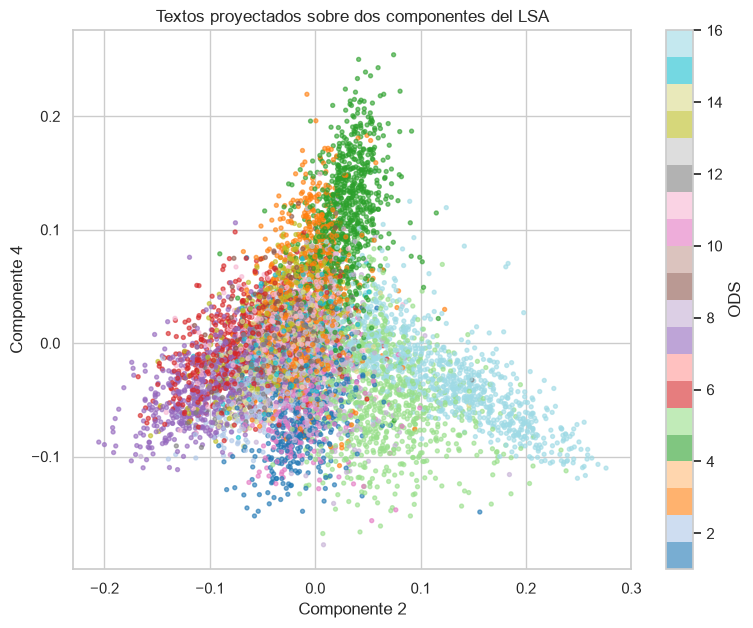

In [12]:
coords = lsa.transform(tfidf_train)
plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 1], coords[:, 3], c=y_train, cmap='tab20', s=8, alpha=0.6)
plt.colorbar(sc, label='ODS')
plt.xlabel('Componente 2'); plt.ylabel('Componente 4')
plt.title('Textos proyectados sobre dos componentes del LSA')
plt.show()

Proyectando los textos sobre las componentes 2 y 4 (las que identificamos como derechos humanos y educación) ya se distinguen grupos de color: los textos del mismo ODS tienden a caer juntos. Con solo dos dimensiones hay mucho solapamiento, pero confirma que el espacio reducido conserva información útil para separar clases.

## 8. ¿Cuántas componentes usar para clasificar?

Quince componentes sirven para leer tópicos, pero pierden demasiada información para separar 16 clases. Miramos cómo crece la varianza explicada al aumentar el número de componentes para escoger un valor razonable.

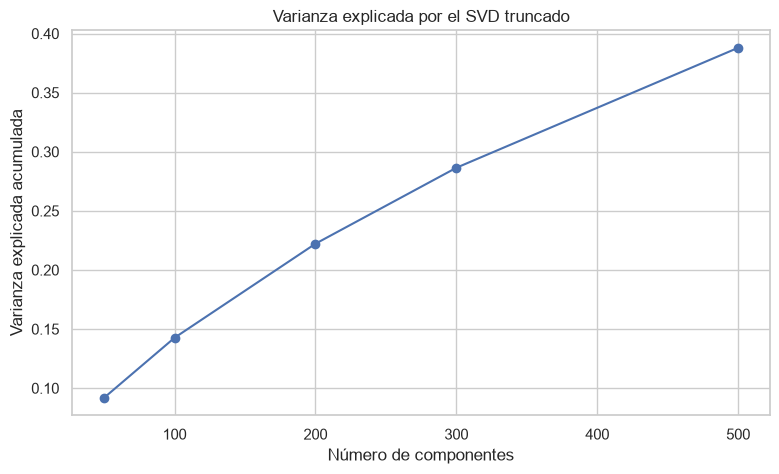

  50 componentes -> 9.19%
 100 componentes -> 14.26%
 200 componentes -> 22.22%
 300 componentes -> 28.65%
 500 componentes -> 38.80%


In [13]:
valores = [50, 100, 200, 300, 500]
varianzas = [TruncatedSVD(n_components=n, random_state=RANDOM_STATE)
             .fit(tfidf_train).explained_variance_ratio_.sum() for n in valores]

plt.plot(valores, varianzas, marker='o')
plt.xlabel('Número de componentes'); plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada por el SVD truncado')
plt.show()
for n, v in zip(valores, varianzas):
    print(f'{n:4d} componentes -> {v:.2%}')

La curva no tiene un codo marcado, algo típico de las matrices TF-IDF: la varianza se reparte muy gradualmente. Pasar de 200 a 300 componentes añade unos 6 puntos de varianza, mientras que llegar a 500 añade 10 puntos más pero duplica el costo de cómputo. Nos quedamos con un rango de 200 a 300 componentes y dejamos que la búsqueda de hiperparámetros decida el valor final. En cualquier caso, pasamos de más de 12.000 columnas a unos cientos, lo que reduce el espacio de entrada en casi dos órdenes de magnitud.

## 9. Construcción del pipeline y comparación de algoritmos

El *pipeline* encadena los tres pasos: vectorización TF-IDF, reducción con SVD y modelo de clasificación. La ventaja es que todo el procesamiento queda encapsulado en un solo objeto: al hacer `fit()` las transformaciones se aprenden solo con los datos de entrenamiento, y al hacer `predict()` se aplican automáticamente. Esto evita fugas de información y permite guardar el flujo completo en un solo archivo para la aplicación.

Comparamos tres algoritmos con validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento:

- **Regresión logística**: el modelo del tutorial, sencillo y con probabilidades directas.
- **LinearSVC** (máquina de vectores de soporte lineal): suele funcionar muy bien en clasificación de texto, porque busca el margen máximo entre clases y tolera bien espacios de alta dimensión.
- **Random Forest**: un modelo no lineal, para comprobar si la frontera entre ODS necesita algo más que un separador lineal.

**Métrica: F1 macro.** No usamos la exactitud porque las clases están desbalanceadas y la exactitud premiaría acertar en los ODS con más textos. El F1 macro promedia el F1 de cada clase dándoles el mismo peso, de modo que fallar sistemáticamente en el ODS 12 (el más pequeño) penaliza tanto como fallar en el ODS 16. Para este problema tiene sentido: todos los objetivos importan igual.

In [14]:
from tempfile import mkdtemp

# El vectorizador es el paso más costoso. Con `memory` el pipeline guarda en
# caché los pasos ya calculados y no repite el procesamiento de texto en cada
# combinación de la validación cruzada.
cache = mkdtemp()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos = {
    'Regresión logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LinearSVC': LinearSVC(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

for nombre, modelo in modelos.items():
    pipe = Pipeline([('tfidf', vectorizador),
                     ('svd', TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
                     ('modelo', modelo)], memory=cache)
    puntajes = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    print(f'{nombre:22s} F1 macro = {puntajes.mean():.4f} (desv. {puntajes.std():.4f})')

Regresión logística    F1 macro = 0.8351 (desv. 0.0088)


LinearSVC              F1 macro = 0.8525 (desv. 0.0104)


Random Forest          F1 macro = 0.7988 (desv. 0.0151)


**LinearSVC es el mejor** con un F1 macro de 0,853, por encima de la regresión logística (0,835) y bastante por encima del Random Forest (0,799). El resultado es el esperado por dos razones. Primero, en texto las clases suelen ser separables linealmente una vez proyectadas en el espacio LSA, y las SVM lineales están diseñadas para encontrar el mejor margen en esa situación. Segundo, el Random Forest hace cortes sobre variables individuales, y las componentes del SVD son combinaciones densas de miles de palabras donde ningún umbral suelto resulta muy informativo; además es el modelo con mayor desviación entre particiones.

Seguimos entonces con LinearSVC.

## 10. Búsqueda de hiperparámetros

Ajustamos con `GridSearchCV` dos cosas a la vez: el número de componentes del SVD y el parámetro de regularización `C` de la SVM. Buscar ambos dentro del mismo *pipeline* es importante porque están relacionados: cuantas más componentes, más flexible es el espacio y distinta puede ser la regularización adecuada. Un `C` pequeño regulariza más (margen amplio, tolera errores) y uno grande ajusta más a los datos de entrenamiento.

In [15]:
pipeline = Pipeline([('tfidf', vectorizador),
                     ('svd', TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
                     ('modelo', LinearSVC(random_state=RANDOM_STATE))], memory=cache)

rejilla = {'svd__n_components': [200, 300], 'modelo__C': [0.5, 1, 5]}
busqueda = GridSearchCV(pipeline, rejilla, cv=cv, scoring='f1_macro', verbose=1)
busqueda.fit(X_train, y_train)

print('\nMejores parámetros:', busqueda.best_params_)
print(f'Mejor F1 macro en validación cruzada: {busqueda.best_score_:.4f}')
pd.DataFrame(busqueda.cv_results_)[['param_svd__n_components', 'param_modelo__C',
                                    'mean_test_score', 'std_test_score']]

Fitting 5 folds for each of 6 candidates, totalling 30 fits



Mejores parámetros: {'modelo__C': 0.5, 'svd__n_components': 300}
Mejor F1 macro en validación cruzada: 0.8531


,param_svd__n_components,param_modelo__C,mean_test_score,std_test_score
0,200,0.5,0.846019,0.009053
1,300,0.5,0.853145,0.008732
2,200,1.0,0.845337,0.008981
3,300,1.0,0.852514,0.010382
4,200,5.0,0.841182,0.007576
5,300,5.0,0.845339,0.004160


La mejor combinación es **300 componentes con `C = 0,5`**, con un F1 macro de 0,853 en validación cruzada. Dos observaciones sobre la tabla:

- El número de componentes pesa más que la regularización: con 300 componentes todas las configuraciones superan a las de 200, lo que confirma que 200 dimensiones se quedan cortas.
- Dentro de cada tamaño, el mejor `C` es el más pequeño y el rendimiento baja al llegar a 5. Es decir, el modelo prefiere estar más regularizado, señal de que con menos regularización empezaría a sobreajustarse al vocabulario del conjunto de entrenamiento.

## 11. Evaluación sobre el conjunto de prueba (actividad 4)

Ahora sí evaluamos con los 1.932 textos que apartamos al comienzo y que el modelo nunca vio, ni siquiera para construir el vocabulario TF-IDF.

In [16]:
modelo_final = busqueda.best_estimator_
y_pred = modelo_final.predict(X_test)

print(f'Exactitud: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 macro:  {f1_score(y_test, y_pred, average="macro"):.4f}\n')
print(classification_report(y_test, y_pred,
      target_names=[f'ODS {i} - {NOMBRES_ODS[i]}' for i in sorted(y.unique())]))

Exactitud: 0.8815
F1 macro:  0.8552

                                                 precision    recall  f1-score   support

                      ODS 1 - Fin de la pobreza       0.86      0.77      0.81       101
                            ODS 2 - Hambre cero       0.79      0.86      0.83        74
                      ODS 3 - Salud y bienestar       0.93      0.91      0.92       179
                   ODS 4 - Educación de calidad       0.90      0.98      0.94       205
                     ODS 5 - Igualdad de género       0.91      0.95      0.93       214
              ODS 6 - Agua limpia y saneamiento       0.92      0.94      0.93       139
    ODS 7 - Energía asequible y no contaminante       0.89      0.94      0.91       158
ODS 8 - Trabajo decente y crecimiento económico       0.65      0.62      0.64        89
ODS 9 - Industria, innovación e infraestructura       0.77      0.72      0.75        69
        ODS 10 - Reducción de las desigualdades       0.78      0.60    

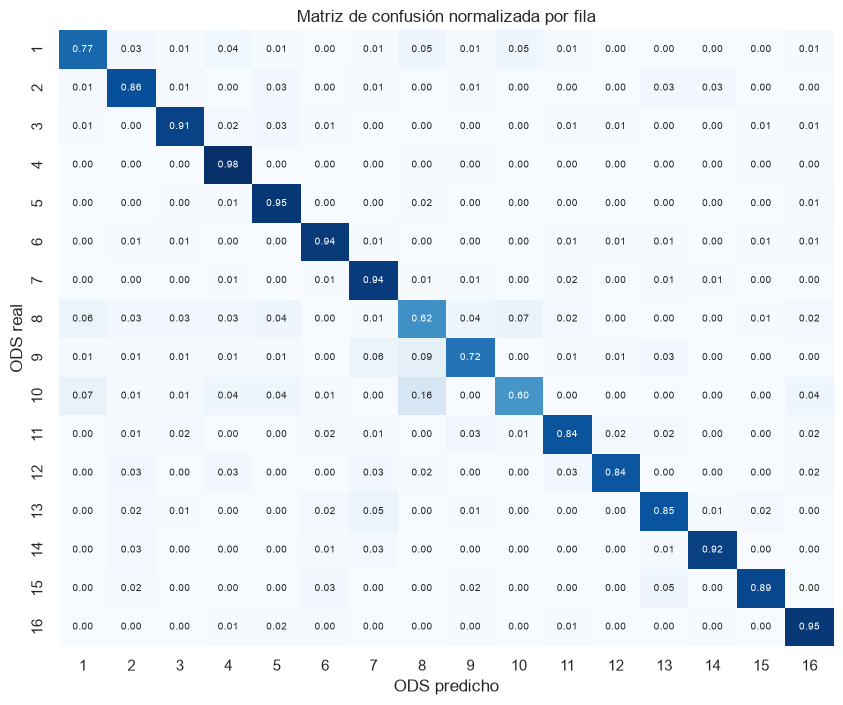

In [17]:
etiquetas = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=etiquetas, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=etiquetas, yticklabels=etiquetas, annot_kws={'size': 7})
plt.xlabel('ODS predicho'); plt.ylabel('ODS real')
plt.title('Matriz de confusión normalizada por fila')
plt.show()

### Análisis de los resultados

El modelo alcanza una **exactitud del 88% y un F1 macro de 0,855** sobre textos no vistos. Para un problema de 16 clases, donde el azar acertaría alrededor del 6%, es un desempeño alto. Además la diferencia con el 0,853 de validación cruzada es mínima, lo que indica que el modelo generaliza y no está sobreajustado.

El rendimiento no es parejo entre objetivos. Los mejor clasificados son el **ODS 4** (educación, F1 de 0,94), el **ODS 16** (paz y justicia, 0,94), el **ODS 5** (género, 0,93), el **ODS 6** (agua, 0,93), el **ODS 14** (vida submarina, 0,93) y el **ODS 3** (salud, 0,92). Todos tienen un vocabulario muy propio: "escuela", "docente", "tribunal", "agua subterránea", "océano", "paciente" aparecen casi solo en sus respectivos objetivos. No es casualidad que sean los mismos temas que el LSA había separado en tópicos limpios.

Los peores son el **ODS 8** (trabajo decente, F1 de 0,64), el **ODS 10** (reducción de desigualdades, 0,68) y el **ODS 9** (industria e innovación, 0,75). En la matriz de confusión se ve que se confunden justamente entre ellos y con el **ODS 1** (pobreza): 11 textos del ODS 10 fueron clasificados como ODS 8, y hay intercambios en ambos sentidos entre los ODS 1, 8, 9 y 10.

Esta confusión es razonable y no es un defecto del modelo. Los cuatro objetivos hablan del mismo campo semántico: empleo, ingresos, brechas económicas, crecimiento y desarrollo productivo. Un texto sobre desempleo juvenil puede pertenecer legítimamente al ODS 8 o al ODS 10 según el enfoque del autor, y la propia Agenda 2030 admite que los objetivos están interrelacionados. A esto se suma que el ODS 9 y el ODS 10 están entre los menos representados del conjunto, con unos 350 textos cada uno, así que el modelo tiene menos ejemplos para aprender a distinguirlos.

## 12. Clasificación de textos del conjunto de prueba

El enunciado pide mostrar la clasificación de al menos cuatro textos que no se usaron en el aprendizaje. Tomamos seis al azar del conjunto de prueba. Como LinearSVC no entrega probabilidades, usamos `decision_function()`, que devuelve un puntaje por clase: mientras más alto, más seguro está el modelo de esa clase.

In [18]:
ejemplos = X_test.sample(6, random_state=7)
puntajes = modelo_final.decision_function(ejemplos)
clases = modelo_final.classes_

for pos, (idx, texto) in enumerate(ejemplos.items()):
    real, pred = y_test[idx], clases[puntajes[pos].argmax()]
    top3 = clases[np.argsort(puntajes[pos])[::-1][:3]]
    print('=' * 100)
    print(f'TEXTO: {texto[:260]}...')
    print(f'  ODS real     : {real:2d} - {NOMBRES_ODS[real]}')
    print(f'  ODS predicho : {pred:2d} - {NOMBRES_ODS[pred]}   {"CORRECTO" if real == pred else "INCORRECTO"}')
    print(f'  Top 3        : ' + ' | '.join(f'ODS {c} ({puntajes[pos][list(clases).index(c)]:+.2f})' for c in top3))

TEXTO: Esta es la razón por la que las redes de calefacción urbana tienen el potencial de ser muy eficientes: desde una perspectiva de sistemas, reduce la demanda de energía primaria. Como ejemplo, el sistema de vapor de distrito actual en Manhattan en Nueva York ya ...
  ODS real     :  7 - Energía asequible y no contaminante
  ODS predicho :  7 - Energía asequible y no contaminante   CORRECTO
  Top 3        : ODS 7 (+0.00) | ODS 11 (-0.61) | ODS 3 (-0.95)
TEXTO: Si bien la infraestructura tiene efectos sustanciales en el crecimiento que pueden variar según los países, el tiempo y dentro de los subsectores de infraestructura (véanse, por ejemplo, Estache y Garsous, 2012, y Dissou y Didic, 2013), el desarrollo de la inf...
  ODS real     :  9 - Industria, innovación e infraestructura
  ODS predicho :  1 - Fin de la pobreza   INCORRECTO
  Top 3        : ODS 1 (-0.07) | ODS 6 (-0.49) | ODS 9 (-0.60)
TEXTO: Sin embargo, no toda formulación de políticas tiene un propósito primario de salud

El modelo acierta en la mayoría de los ejemplos, y cuando falla la respuesta correcta suele aparecer en el segundo o tercer lugar del ranking, con puntajes muy cercanos entre sí. Esto refuerza la idea anterior: los errores se concentran en textos que genuinamente tocan varios objetivos. Para un usuario del UNFPA, mostrar los tres ODS más probables en lugar de uno solo sería más útil que forzar una única respuesta.

Probamos también con textos escritos por nosotros, que no vienen del conjunto de datos, para simular lo que hará la aplicación de Streamlit.

In [19]:
textos_nuevos = [
    'Es urgente ampliar la cobertura de acueducto y alcantarillado en las zonas rurales, '
    'donde miles de familias todavía consumen agua sin ningún tratamiento de potabilización.',
    'Las mujeres siguen recibiendo salarios menores que los hombres por el mismo trabajo y '
    'están subrepresentadas en los cargos directivos de las empresas.',
    'La instalación de paneles solares y parques eólicos permitiría reducir la dependencia de '
    'los combustibles fósiles y llevar electricidad limpia a comunidades aisladas.',
    'El aumento de la temperatura del planeta y el deshielo de los polos exigen medidas '
    'inmediatas de mitigación y adaptación frente al calentamiento global.',
]

for texto in textos_nuevos:
    pred = modelo_final.predict([texto])[0]
    print(f'"{texto[:70]}..."\n  -> ODS {pred}: {NOMBRES_ODS[pred]}\n')

"Es urgente ampliar la cobertura de acueducto y alcantarillado en las z..."
  -> ODS 6: Agua limpia y saneamiento

"Las mujeres siguen recibiendo salarios menores que los hombres por el ..."
  -> ODS 5: Igualdad de género

"La instalación de paneles solares y parques eólicos permitiría reducir..."
  -> ODS 7: Energía asequible y no contaminante

"El aumento de la temperatura del planeta y el deshielo de los polos ex..."
  -> ODS 13: Acción por el clima



Con textos redactados desde cero el modelo asigna los objetivos esperados: agua potable al ODS 6, brecha salarial de género al ODS 5, energías renovables al ODS 7 y calentamiento global al ODS 13. Esto confirma que el *pipeline* funciona de extremo a extremo con entradas libres, que es exactamente lo que necesita la aplicación.

## 13. Guardado del modelo

Guardamos el *pipeline* completo con `joblib`. Al estar todo encapsulado, el archivo contiene el vectorizador con su vocabulario, la matriz del SVD y la SVM entrenada, así que la aplicación solo tendrá que cargarlo y llamar a `predict()` con el texto crudo.

In [20]:
joblib.dump(modelo_final, 'modelo_ods.joblib')

# Comprobamos que se pueda cargar y usar, tal como hará la aplicación.
modelo_cargado = joblib.load('modelo_ods.joblib')
prueba = 'Muchos niños abandonan la escuela primaria por falta de docentes y de material educativo.'
pred = modelo_cargado.predict([prueba])[0]
print(f'Modelo cargado correctamente. Predicción de prueba -> ODS {pred}: {NOMBRES_ODS[pred]}')

Modelo cargado correctamente. Predicción de prueba -> ODS 4: Educación de calidad


## 14. Conclusiones

Construimos una solución completa que clasifica un texto en español según el ODS con el que se relaciona, con una exactitud del 88% y un F1 macro de 0,855 sobre textos que nunca fueron usados durante el entrenamiento.

Las decisiones que más influyeron en el resultado fueron:

- **El preprocesamiento en español.** Cambiar el *stemmer* de Porter por el de Snowball y añadir palabras vacías propias del dominio evitó que los tópicos y el modelo se llenaran de términos genéricos como "desarrollo" u "objetivo".
- **El pesado TF-IDF con bigramas.** Conservar parejas como "cambio climático" o "igualdad de género" aporta significado que las palabras sueltas pierden.
- **La reducción de dimensionalidad con SVD truncado.** Pasamos de más de 12.000 términos a 300 componentes, lo que hace el entrenamiento manejable y evita el sobreajuste sin perder capacidad de discriminación.
- **El encapsulado en un pipeline.** Garantiza que las transformaciones se aprendan solo con los datos de entrenamiento y permite reutilizar el flujo completo en la aplicación.

El LSA cumplió un doble papel: como modelo de tópicos mostró que la estructura latente del corpus se corresponde con temas de los ODS sin necesidad de las etiquetas, y como técnica de reducción alimentó al clasificador.

**Limitaciones.** El conjunto no tiene textos del ODS 17, de modo que el modelo nunca podrá identificarlo. La asignación es de una sola etiqueta, cuando en la realidad muchos textos se relacionan con varios objetivos a la vez; un enfoque multietiqueta representaría mejor el problema. Además el desempeño baja en los ODS 8, 9 y 10, que comparten el campo semántico económico.

**Posibles mejoras.** Ampliar el número de textos de las clases minoritarias, probar representaciones basadas en *embeddings* contextuales en español como BETO, o entregar al usuario los tres ODS más probables en lugar de una única respuesta.